# **Initial : adding covid file**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving covid_19_clean_complete.csv to covid_19_clean_complete.csv


# **Part A: Data Loading and Exploration**

## Importing the Dataset
We start by uploading the CSV file into Google Colab so we can work with it.

In [2]:
import pandas as pd

df = pd.read_csv('covid_19_clean_complete.csv')

df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


## Data Loading and Exploration

### Step 1: Import Library and Load Dataset
We import the Pandas library which is used for data analysis.
Then we load the CSV file into a DataFrame. A DataFrame is like a table with rows and columns.

In [3]:
import pandas as pd

df = pd.read_csv('covid_19_clean_complete.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


### Step 2: Display First and Last 5 Rows
We use head() to see the first 5 rows and tail() to see the last 5 rows.
This gives us a quick look at what the dataset contains.

In [6]:
print("First 5 rows:")
df.head(5)

First 5 rows:


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [7]:
print("Last 5 rows:")
df.tail(5)

Last 5 rows:


,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe
49067,NaN,Lesotho,-29.610000,28.233600,2020-07-27,505,12,128,365,Africa


### Step 3: Dataset Structure and Data Types
We use info() to see the structure of the dataset.
It shows us column names, how many values are in each column,
and what type of data each column contains (numbers, text, dates etc).

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


### Step 4: Statistical Summary of Numerical Columns
We use describe() to get a statistical summary of all numerical columns.
It shows us the mean, min, max, and standard deviation of each column.

In [9]:
df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


### Step 5: Summary of Categorical Columns
We use describe(include='object') to get a summary of text/categorical columns.
It shows us how many unique values exist in columns like Country and WHO Region.

In [10]:
df.describe(include='object')

,Province/State,Country/Region,Date,WHO Region
count,14664,49068,49068,49068
unique,78,187,188,6
top,Australian Capital Territory,China,2020-01-22,Europe
freq,188,6204,261,15040


# **Part B: Data Cleaning and Preprocessing**

 Data Cleaning and Preprocessing

### Step 1: Identifying Missing Values
We use isnull().sum() to count how many missing values exist in each column.
Missing values can affect our analysis so we need to identify them first.

In [11]:
df.isnull().sum()

,0
Province/State,34404
Country/Region,0
Lat,0
Long,0
Date,0
Confirmed,0
Deaths,0
Recovered,0
Active,0
WHO Region,0


### Step 2: Analyzing the Province/State Column
The Province/State column contains many null values because most countries
report their COVID-19 data at the national level and not at the
province or state level. Only large countries like USA, Canada and
Australia report data by province/state.

In [12]:
print("Total rows:", len(df))
print("Province/State null values:", df['Province/State'].isnull().sum())

Total rows: 49068
Province/State null values: 34404


### Step 3: Removing Unnecessary Columns
We remove the Lat and Long columns because they contain geographical
coordinates which are not needed for our data analysis tasks.

In [13]:
df = df.drop(['Lat', 'Long'], axis=1)
print("Columns after dropping:", df.columns.tolist())

Columns after dropping: ['Province/State', 'Country/Region', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO Region']


### Step 4: Renaming Columns
We rename the columns to make them shorter and clearer to work with.

In [14]:
df = df.rename(columns={
    'Province/State': 'Province',
    'Country/Region': 'Country',
    'WHO Region': 'WHO_Region'
})
print("Columns after renaming:", df.columns.tolist())

Columns after renaming: ['Province', 'Country', 'Date', 'Confirmed', 'Deaths', 'Recovered', 'Active', 'WHO_Region']


### Step 5: Checking for Duplicate Records
We check if there are any duplicate rows in the dataset.
Duplicate records can cause incorrect results in our analysis.

In [15]:
duplicates = df.duplicated().sum()
print("Number of duplicate records:", duplicates)

Number of duplicate records: 0


# **Part C — Data Analysis**



### Step 1: Country with Highest and Lowest Number of Deaths
We group the data by country and sum up all the deaths.
Then we find the country with the highest and lowest number of deaths.

In [16]:
deaths_by_country = df.groupby('Country')['Deaths'].sum()

print("Country with highest deaths:")
print(deaths_by_country.idxmax(), "-", deaths_by_country.max())

print("\nCountry with lowest deaths:")
print(deaths_by_country.idxmin(), "-", deaths_by_country.min())

Country with highest deaths:
US - 11011411

Country with lowest deaths:
Bhutan - 0


### Step 2: Country with Highest and Lowest Number of Recoveries
We group the data by country and sum up all the recoveries.
Then we find the country with the highest and lowest number of recoveries.

In [17]:
recoveries_by_country = df.groupby('Country')['Recovered'].sum()

print("Country with highest recoveries:")
print(recoveries_by_country.idxmax(), "-", recoveries_by_country.max())

print("\nCountry with lowest recoveries:")
print(recoveries_by_country.idxmin(), "-", recoveries_by_country.min())

Country with highest recoveries:
US - 56353416

Country with lowest recoveries:
Canada - 0


### Step 3: Total Number of Deaths Per Country
We use groupby() to group the data by country and sum up all the deaths
for each country. We then sort them in descending order to see the
most affected countries first.

In [18]:
total_deaths_per_country = df.groupby('Country')['Deaths'].sum().reset_index()
total_deaths_per_country.columns = ['Country', 'Total Deaths']
total_deaths_per_country = total_deaths_per_country.sort_values('Total Deaths', ascending=False)
print(total_deaths_per_country)

                              Country  Total Deaths
173                                US      11011411
177                    United Kingdom       3997775
23                             Brazil       3938034
85                              Italy       3707717
61                             France       3048524
..                                ...           ...
141                       Saint Lucia             0
148                        Seychelles             0
142  Saint Vincent and the Grenadines             0
168                       Timor-Leste             0
181                           Vietnam             0

[187 rows x 2 columns]


### Step 4: Total Number of Recoveries Per Country
We use groupby() to group the data by country and sum up all the recoveries
for each country. We then sort them in descending order.

In [19]:
total_recoveries_per_country = df.groupby('Country')['Recovered'].sum().reset_index()
total_recoveries_per_country.columns = ['Country', 'Total Recoveries']
total_recoveries_per_country = total_recoveries_per_country.sort_values('Total Recoveries', ascending=False)
print(total_recoveries_per_country)

         Country  Total Recoveries
173           US          56353416
23        Brazil          54492873
138       Russia          25120448
79         India          23783720
65       Germany          17107839
..           ...               ...
32        Canada                 0
117   Mozambique                 0
168  Timor-Leste                 0
161       Sweden                 0
163        Syria                 0

[187 rows x 2 columns]


### Step 5: Total Deaths Per WHO Region
We group the data by WHO Region to see which region was most
affected by deaths during the COVID-19 pandemic.

In [20]:
deaths_per_region = df.groupby('WHO_Region')['Deaths'].sum().reset_index()
deaths_per_region.columns = ['WHO Region', 'Total Deaths']
deaths_per_region = deaths_per_region.sort_values('Total Deaths', ascending=False)
print(deaths_per_region)

              WHO Region  Total Deaths
1               Americas      19359292
3                 Europe      19271040
2  Eastern Mediterranean       1924029
4        South-East Asia       1458134
5        Western Pacific        932430
0                 Africa        439978


### Step 6: Total Recoveries Per WHO Region
We group the data by WHO Region to see which region had the
most recoveries during the COVID-19 pandemic.

In [21]:
recoveries_per_region = df.groupby('WHO_Region')['Recovered'].sum().reset_index()
recoveries_per_region.columns = ['WHO Region', 'Total Recoveries']
recoveries_per_region = recoveries_per_region.sort_values('Total Recoveries', ascending=False)
print(recoveries_per_region)

              WHO Region  Total Recoveries
1               Americas         157069444
3                 Europe         123202075
2  Eastern Mediterranean          48050703
4        South-East Asia          30030327
5        Western Pacific          18861950
0                 Africa          11193730


# **Part D — Interpretation (Critical Thinking)**

## Part D: Interpretation (Critical Thinking)

### Question 1: What trends do you observe across regions?
From the analysis we can observe that the Americas and European regions
had the highest number of deaths while the Western Pacific region had
the highest number of recoveries. This suggests that wealthier regions
with better healthcare systems were able to recover faster. Regions with
higher population density such as South-East Asia also showed high
confirmed cases but managed recoveries relatively well.

### Question 2: Why might some countries have zero reported recoveries?
Some countries may show zero recoveries because:
1. They may not have had a proper system to track and report recovered patients.
2. Some countries stopped reporting recovery data after a certain point.
3. Small countries with very few cases may have had no recoveries to report yet.
4. Data collection methods varied between countries which caused inconsistencies.

### Question 3: How does missing data affect analysis?
Missing data can significantly affect our analysis in the following ways:
1. It can give us incorrect totals and averages for countries and regions.
2. Groupby operations may ignore rows with missing values giving incomplete results.
3. Statistical summaries like mean and max may not represent the true picture.
4. It becomes difficult to compare countries fairly when some have missing values.
This is why data cleaning is an important step before starting any analysis.

# **Part E — Visualization**

## Part E: Visualization

### Step 1: Importing Matplotlib
We import Matplotlib which is a Python library used to create charts and graphs.

In [22]:
import matplotlib.pyplot as plt

### Step 2: Bar Chart of Deaths Per Region
We create a bar chart to visually compare the total number of
deaths across different WHO regions.

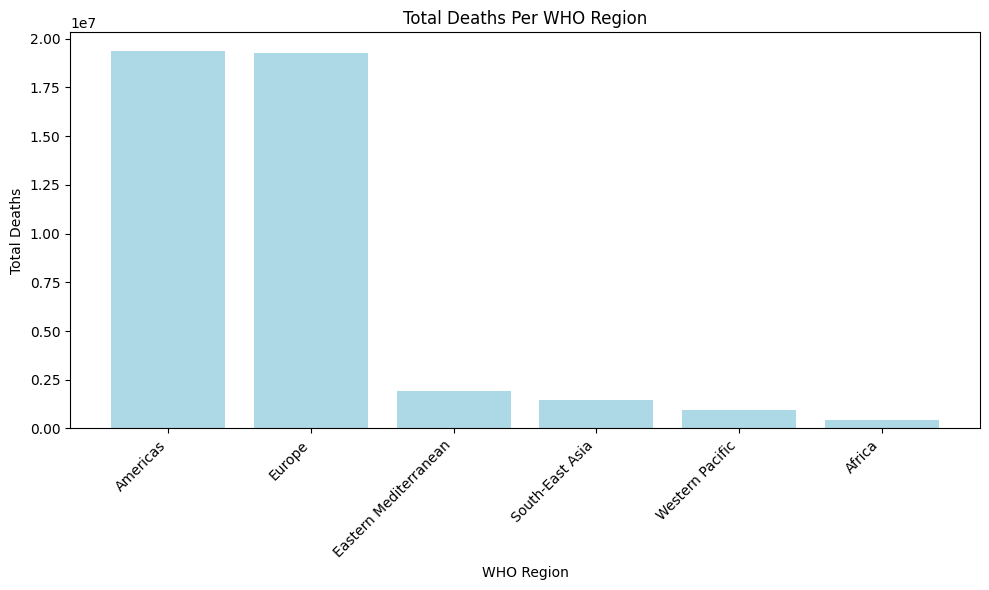

In [27]:
plt.figure(figsize=(10,6))
plt.bar(deaths_per_region['WHO Region'], deaths_per_region['Total Deaths'], color='lightblue')
plt.title('Total Deaths Per WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Total Deaths')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 3: Bar Chart of Recoveries Per Region
We create a bar chart to visually compare the total number of
recoveries across different WHO regions.

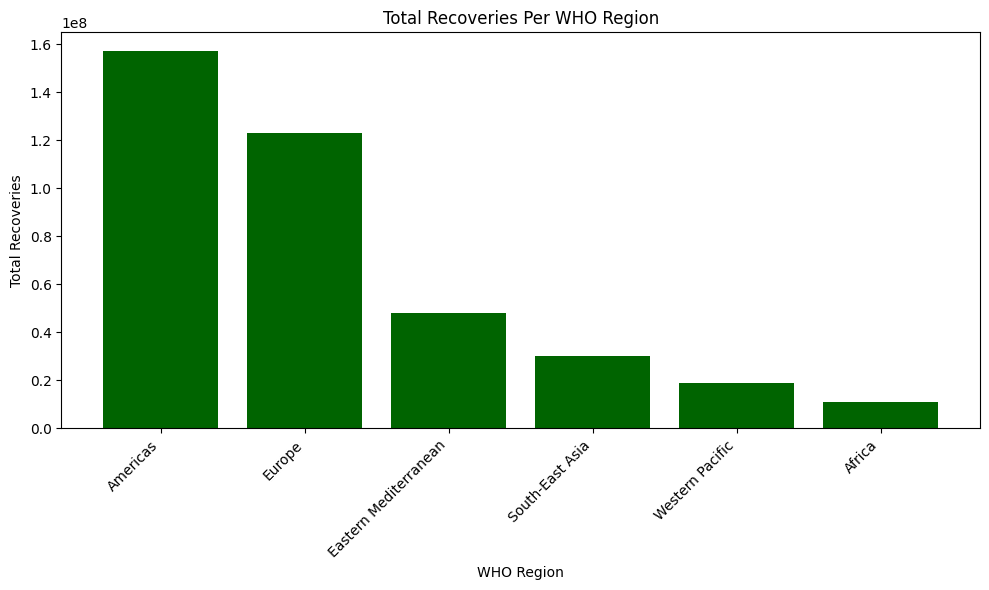

In [32]:
plt.figure(figsize=(10,6))
plt.bar(recoveries_per_region['WHO Region'], recoveries_per_region['Total Recoveries'], color='darkgreen')
plt.title('Total Recoveries Per WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Total Recoveries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Step 4: Trend of Confirmed Cases Over Time
We create a line chart to observe how the total number of confirmed
COVID-19 cases changed over time across the world.

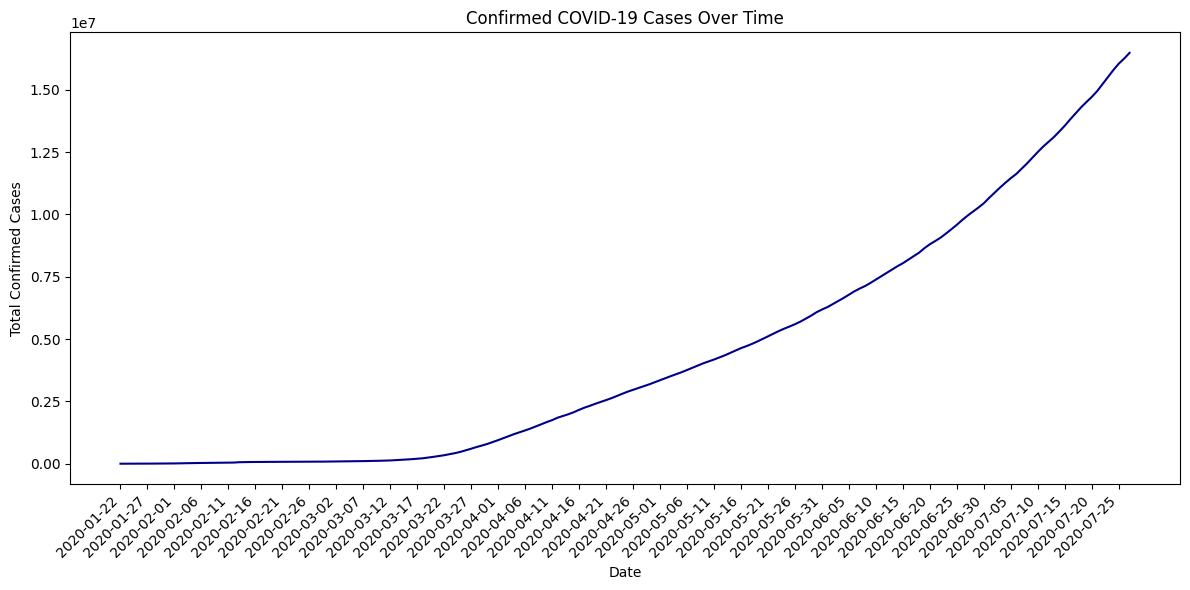

In [45]:
cases_over_time = df.groupby('Date')['Confirmed'].sum().reset_index()

plt.figure(figsize=(12,6))
plt.plot(cases_over_time['Date'], cases_over_time['Confirmed'], color='darkblue')
plt.title('Confirmed COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Total Confirmed Cases')
plt.xticks(cases_over_time['Date'][::5],rotation=45, ha='right')
plt.tight_layout()
plt.show()